# ISyE 6525 HW2 — Question 2

Intensity transformations of `Flower.jpg`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_PATH = Path("Flower.jpg")
with Image.open(IMAGE_PATH) as image:
    flower = image.convert("RGB")

def to_uint8(values, lower=0, upper=255):
    return np.rint(np.clip(values, lower, upper)).astype(np.uint8)

def report_contrast(image, label):
    values = np.asarray(image, dtype=float)
    contrast = values.max() - values.min()
    print(f"{label}: contrast={contrast:.0f}")

def image_and_histogram(image, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title(title)
    axes[0].axis("off")
    values = np.asarray(image, dtype=float)
    counts, _ = np.histogram(image, bins=np.arange(257) - 0.5)
    axes[1].bar(np.arange(256), counts, width=1)
    axes[1].set(xlim=(-0.5, 255.5), xlabel="Intensity", ylabel="Pixel count", title="Histogram")
    assert counts.sum() == image.size
    fig.tight_layout()
    plt.show()

## (a) Original and resized images

Reducing original image to one-third of the width and height, using integer division.

Original (width, height): (768, 512); array shape: (512, 768, 3)
Resized (width, height): (256, 170); array shape: (170, 256, 3)


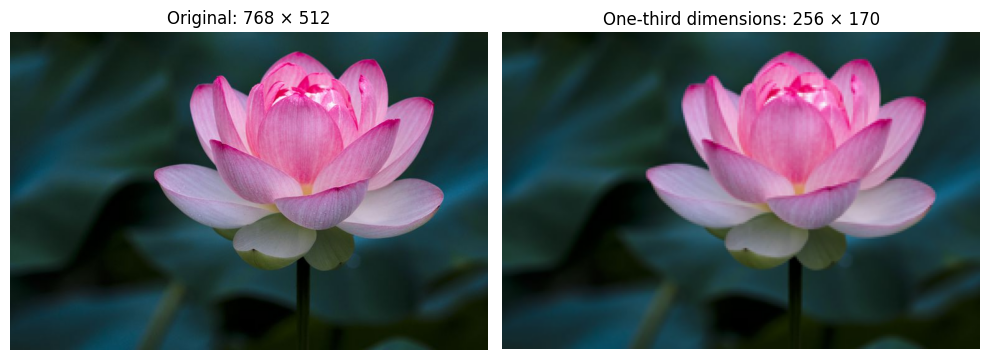

In [2]:
width, height = flower.size
resized = flower.resize((width // 3, height // 3))
print(f"Original (width, height): {flower.size}; array shape: {np.asarray(flower).shape}")
print(f"Resized (width, height): {resized.size}; array shape: {np.asarray(resized).shape}")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, image, title in zip(axes, [flower, resized], ["Original", "One-third dimensions"]):
    ax.imshow(image)
    ax.set_title(f"{title}: {image.size[0]} × {image.size[1]}")
    ax.axis("off")
fig.tight_layout()
plt.show()

## (b) Grayscale and black-and-white images

Use PIL buil-in convert to convert orignal RGB image to grayscale ('L' mode). For BW transformation, a grayscale pixel is white when $f/255>0.45$ (equivalently $f>114.75$), black otherwise.

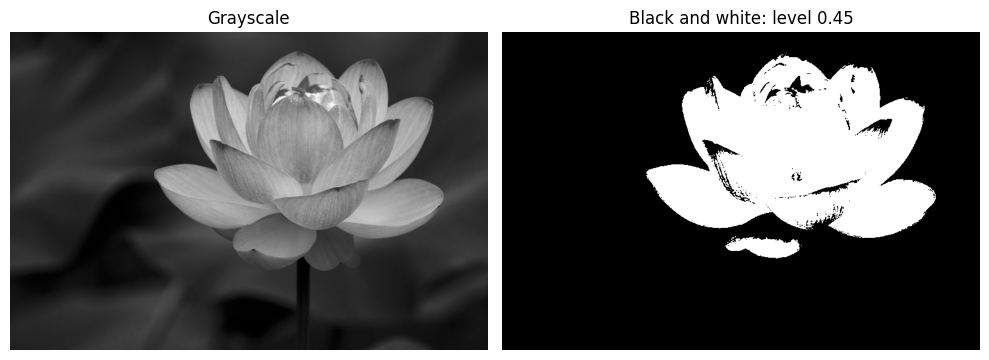

In [3]:
rgb = np.asarray(flower, dtype=float)
gray = np.asarray(flower.convert('L'))
f =  gray.astype(float)
binary_045 = np.where(f / 255.0 > 0.45, 255, 0).astype(np.uint8)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, image, title in zip(axes, [gray, binary_045],
                            ["Grayscale", "Black and white: level 0.45"]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

## (c) Grayscale histogram and contrast

The primary contrast measure is $C=f_{\max}-f_{\min}$.

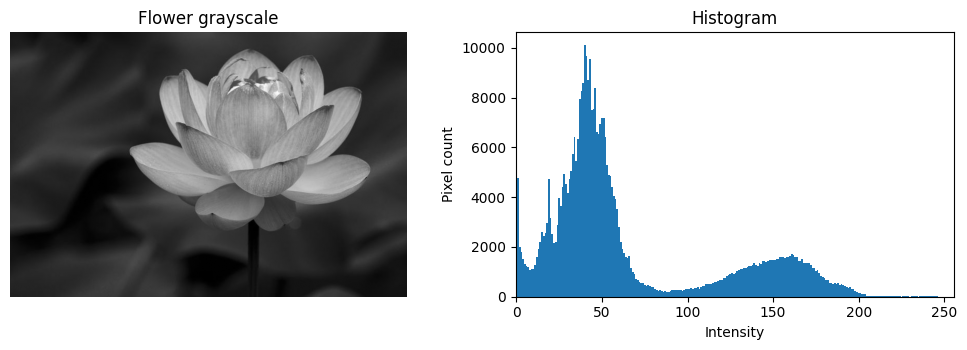

Contrast: contrast=255
Min/max: 0, 255; mean: 66.94
Percentiles [5,25,50,75,95]: [ 12.  34.  46.  90. 171.]
[0, 64): 71.0%
[64, 128): 8.6%
[128, 192): 19.4%
[192, 256): 1.0%


In [4]:
image_and_histogram(f, "Flower grayscale")
report_contrast(gray, "Contrast")
print(f"Min/max: {gray.min()}, {gray.max()}; mean: {f.mean():.2f}")
print("Percentiles [5,25,50,75,95]:", np.percentile(f, [5, 25, 50, 75, 95]))
for low, high in [(0, 64), (64, 128), (128, 192), (192, 256)]:
    print(f"[{low}, {high}): {np.mean((f >= low) & (f < high)):.1%}")

### Interpretation

The histogram has a dominant dark peak around 40 and a smaller broad bright population around 150–170, consistent with the dark background and brighter flower. About 71.0% of pixels are below 64, and only 1.0% are at least 192. The median is 46 and mean is 66.94, so this is predominantly a dark image despite spanning the full 0–255 range.


## (d) Transformations

Each image is displayed using the same fixed [0,255] scale so automatic display normalization cannot hide brightness changes.

### (d.1) Linear

$g=1.4f-20$.

**Purpose:** Increases differences between intensities before clipping while lowering the intercept; saturation loses detail at the extremes.

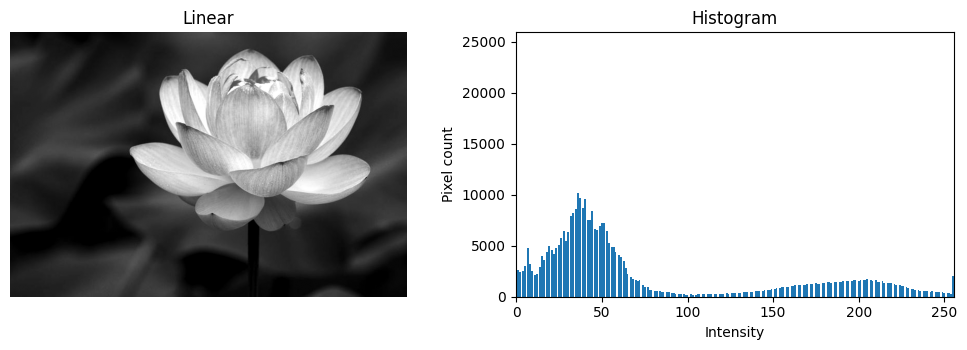

In [5]:
linear = to_uint8(1.4 * f - 20)
image_and_histogram(linear, "Linear")

### (d.2) Log

$g=40\ln(1+f)$.

**Purpose:** Expands differences among low intensities and compresses differences among high intensities; with this coefficient 40, the maximum possible output is about 222.

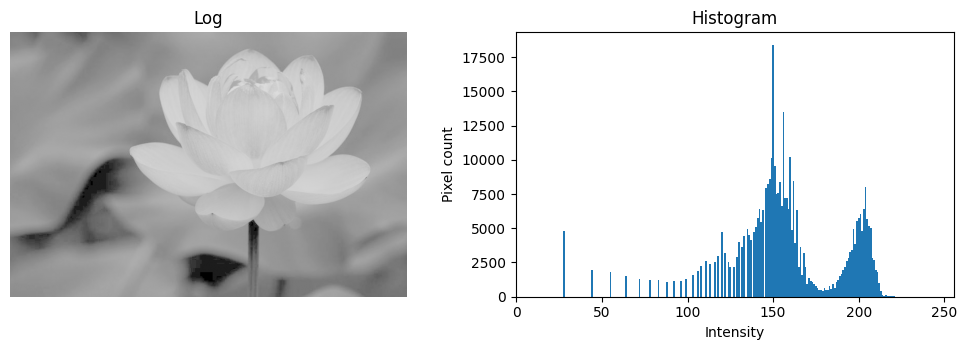

In [6]:
log_image = to_uint8(40 * np.log1p(f))
image_and_histogram(log_image, "Log")

### (d.3) Power law

$g=0.1f^{1.4}$.

**Purpose:** Darkens nonzero intensities on this 0–255 scale and gives relatively more separation to brighter inputs than darker inputs.

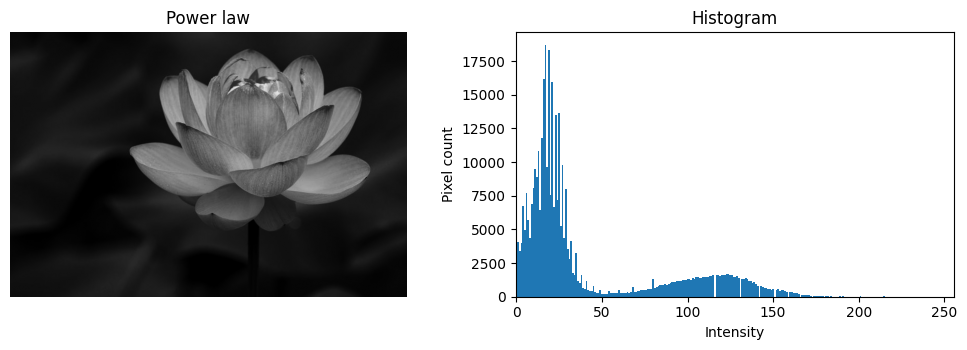

In [7]:
power_image = to_uint8(0.1 * f ** 1.4)
image_and_histogram(power_image, "Power law")

### (d.4) Threshold

$g=255$ for $f>120$, and $g=0$ otherwise.

**Purpose:** Separates pixels into two intensity classes, discarding within-class grayscale detail.

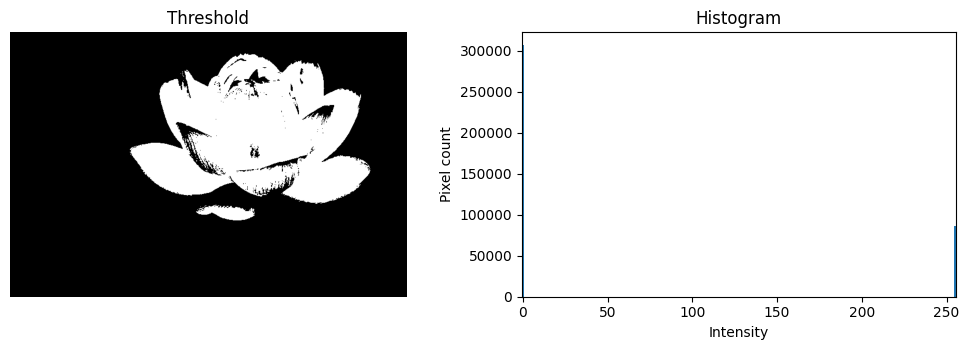

In [8]:
threshold_image = np.where(f > 120, 255, 0).astype(np.uint8)
image_and_histogram(threshold_image, "Threshold")

### (d.5) Histogram shift

$g=\operatorname{clip}_{[25,225]}(f+50)$ under the interval-selective convention stated above.

**Purpose:** Brightens the image intensity, and keeps a smaller range of contrast within the specified interval [25, 225].

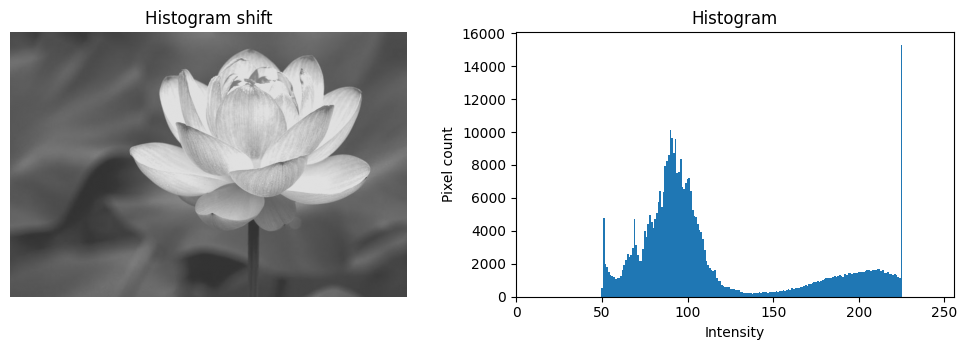

In [9]:
shift_image = to_uint8(f + 50, lower=25, upper=225)
image_and_histogram(shift_image, "Histogram shift")

### (d.6) Histogram stretch

$g=235(f-f_{\min})/(f_{\max}-f_{\min})$. A constant image is mapped to zero to avoid division by zero.

**Purpose:** Maps the observed intensity endpoints to 0 and 235; this expands the range only if the original range is below 235 and otherwise compresses it.

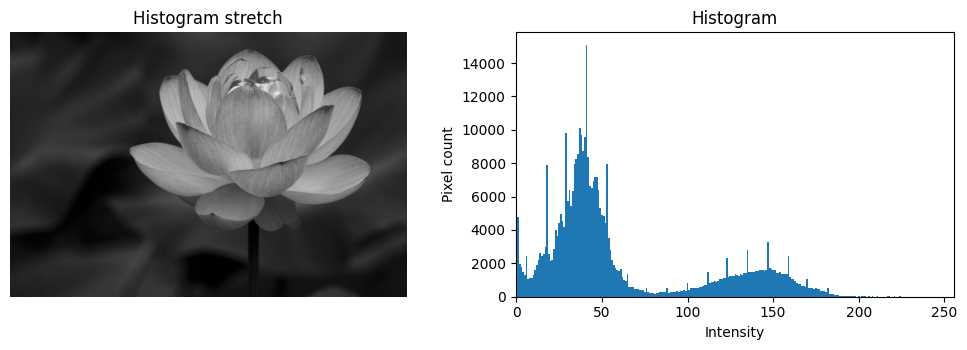

Before stretch: contrast=255
After stretch: contrast=235


In [10]:
span = f.max() - f.min()
stretched = to_uint8(235 * (f - f.min()) / span) if span else np.zeros_like(gray)
image_and_histogram(stretched, "Histogram stretch")
report_contrast(gray, "Before stretch")
report_contrast(stretched, "After stretch")